# **Klasifikasi Kondisi Mental Mahasiswa | Linear Regression**

> Tujuan dari model yaitu untuk memprediksi kondisi mental mahasiswa berdasarkan gaya hidup mahasiswa menggunakan algorithma linear regressi

## **1. Data Understanding**

### 1.1 Import Library

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox

### 1.2 Import Dataset

In [63]:
df = pd.read_csv('student_lifestyle_100k.csv')

### 1.3 Memahami Data

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [65]:
df = df.drop('Student_ID', axis=1)

In [66]:
df.nunique()

Age                     7
Gender                  2
Department              5
CGPA                  237
Sleep_Duration         91
Study_Hours           126
Social_Media_Hours     97
Physical_Activity     150
Stress_Level            9
Depression              2
dtype: int64

In [67]:
print('Nilai Kosong     :',df.isnull().sum().sum())
print('Nilai Duplikat   :',df.duplicated().sum())

Nilai Kosong     : 0
Nilai Duplikat   : 0


In [68]:
cat_col = df.select_dtypes(include=['object', 'category'])
num_col = df.select_dtypes(include='number')

/tmp/ipykernel_58028/1937840374.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=['object', 'category'])


## **2. EDA**

### 2.1 Multivariate Analisis

#### Analisis Statistik

In [69]:
df.describe()

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [70]:
cat_col.describe()

,Gender,Department
count,100000,100000
unique,2,5
top,Male,Science
freq,50120,20071


In [71]:
df['Depression'] = df['Depression'].map({False:0, True:1})
df['Department'] = df['Department'].map({
    'Science':0,
    'Engineering':1,
    'Arts':2,
    'Medical':3,
    'Business':4
})

#### Analisis Korelasi

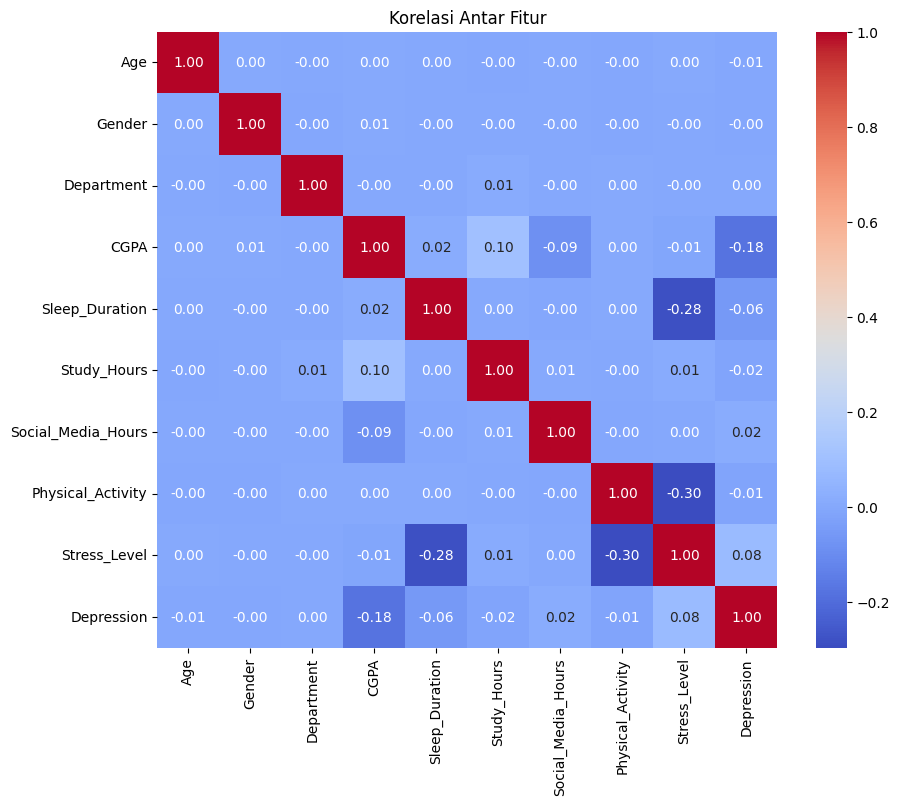

In [115]:

plt.figure(figsize=(10,8))
plt.title('Korelasi Antar Fitur')
sns.heatmap(df.corr(), fmt='.2f', annot=True, cmap='coolwarm')
plt.show()

### 2.2 Univariate Analysis

#### Distribusi Fitur

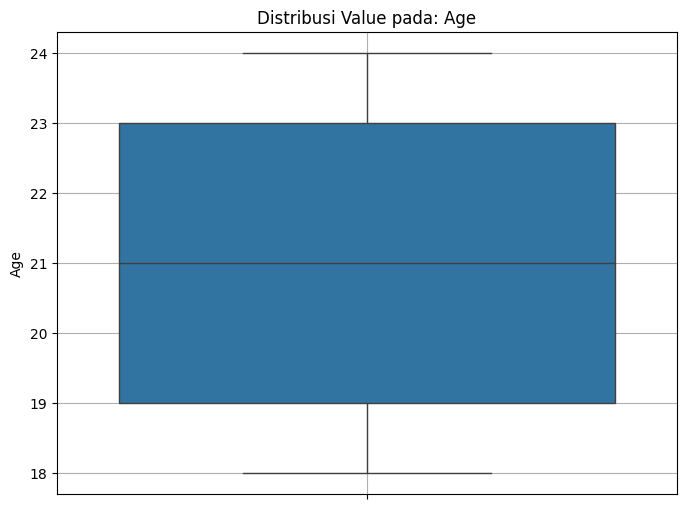

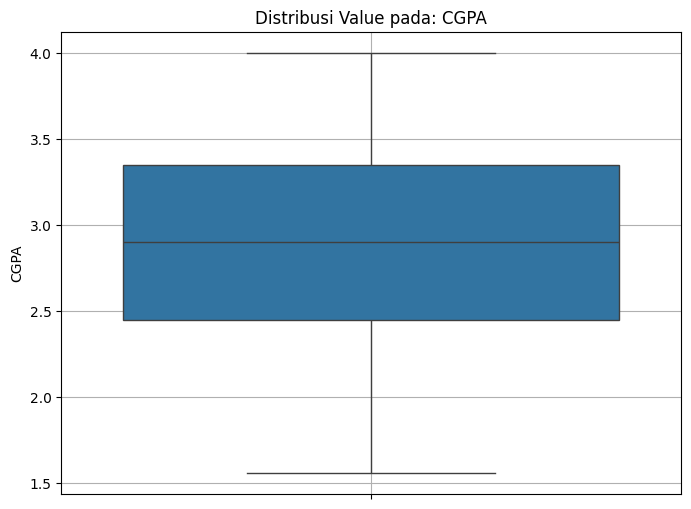

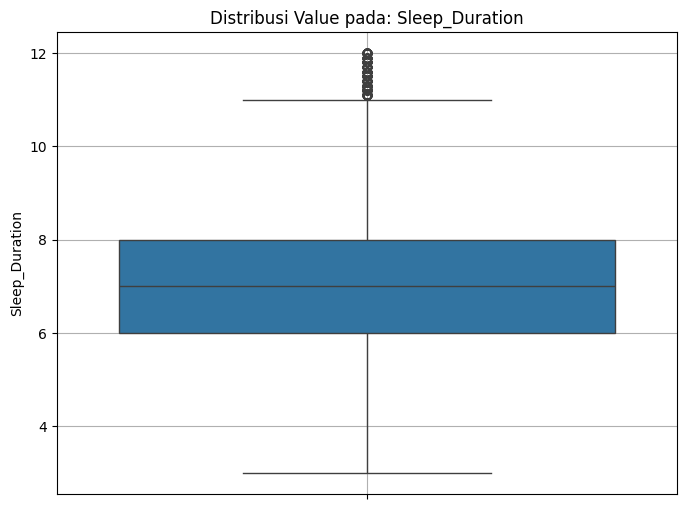

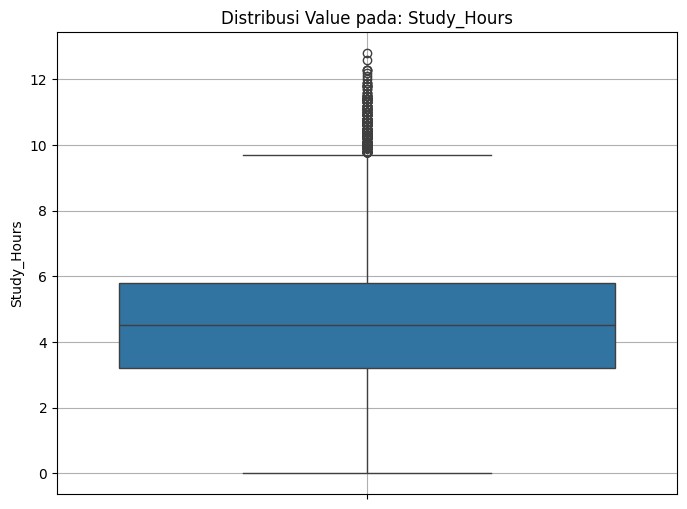

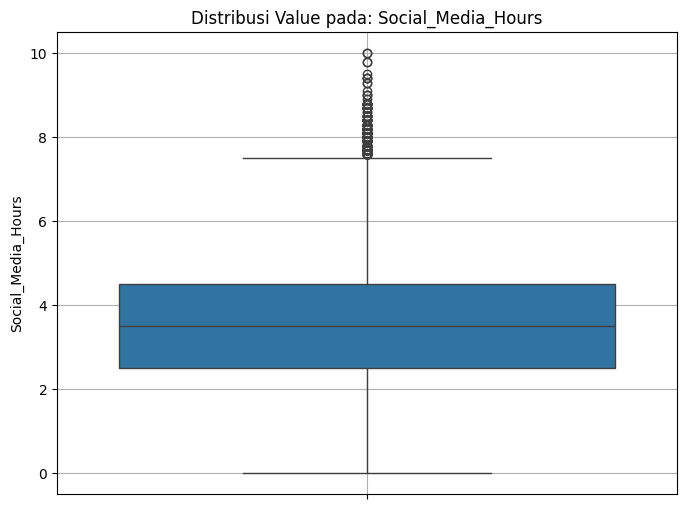

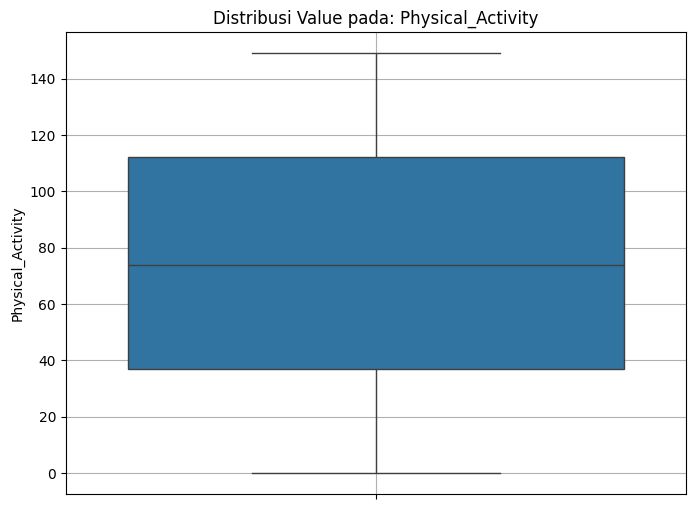

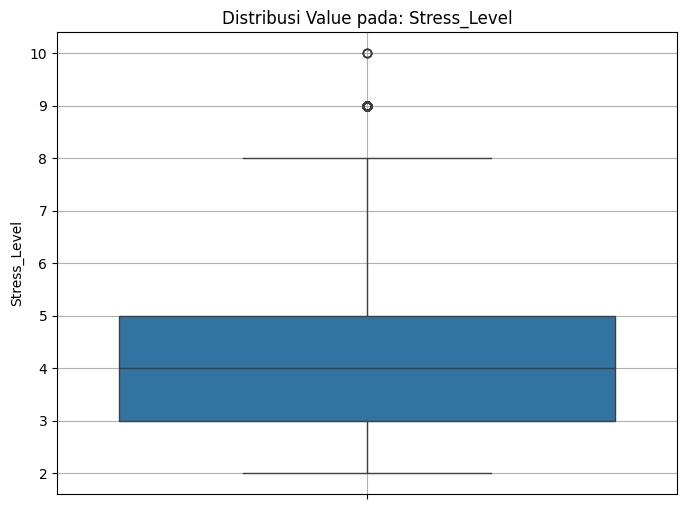

In [73]:
for col in num_col:
    plt.figure(figsize=(8,6))
    plt.title(f'Distribusi Value pada: {col}')
    sns.boxplot(num_col[col])
    plt.grid()
    plt.xticks()
    plt.show()

#### Distribusi Fitur Dan Target

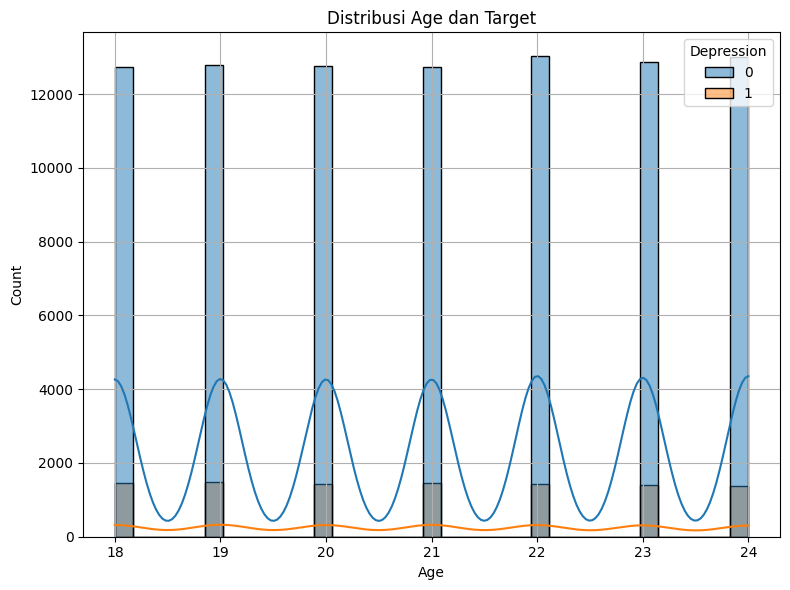

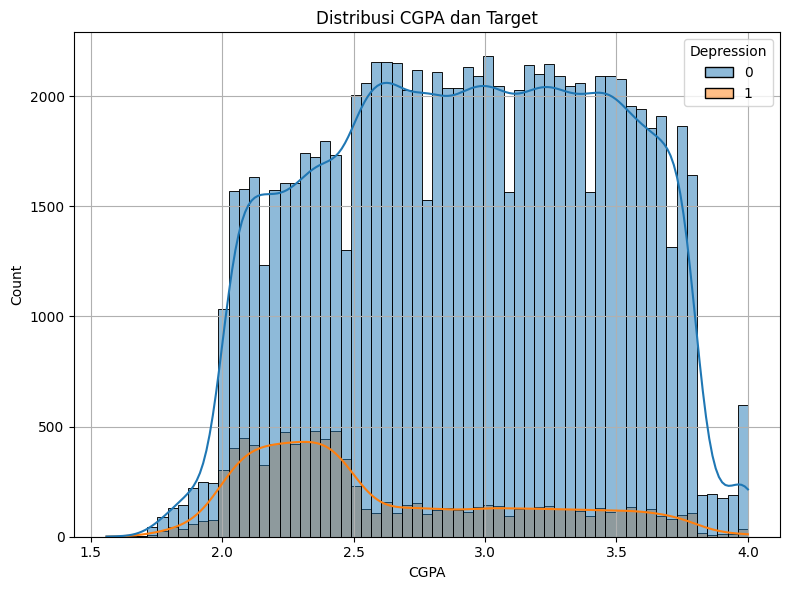

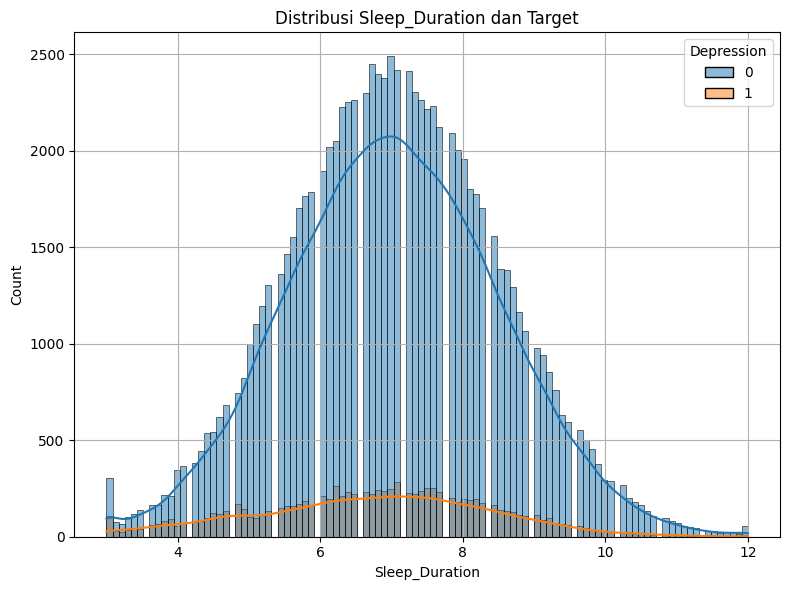

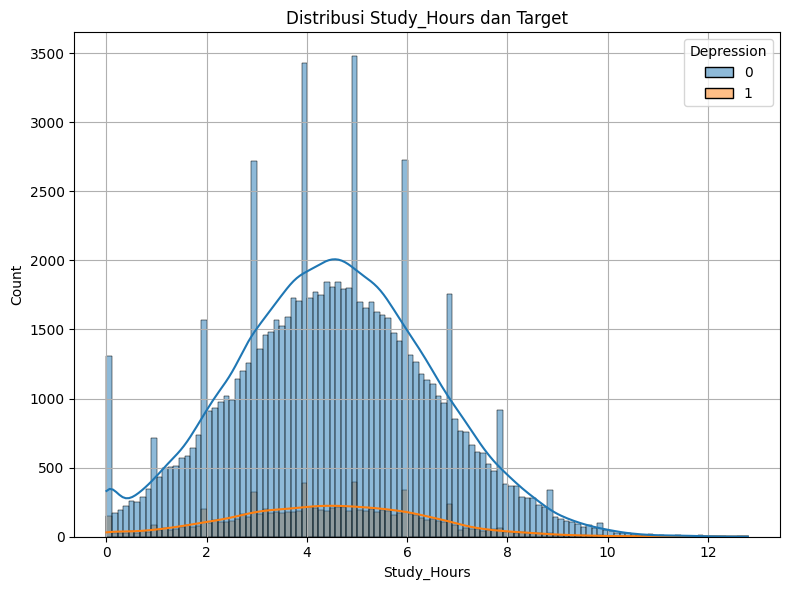

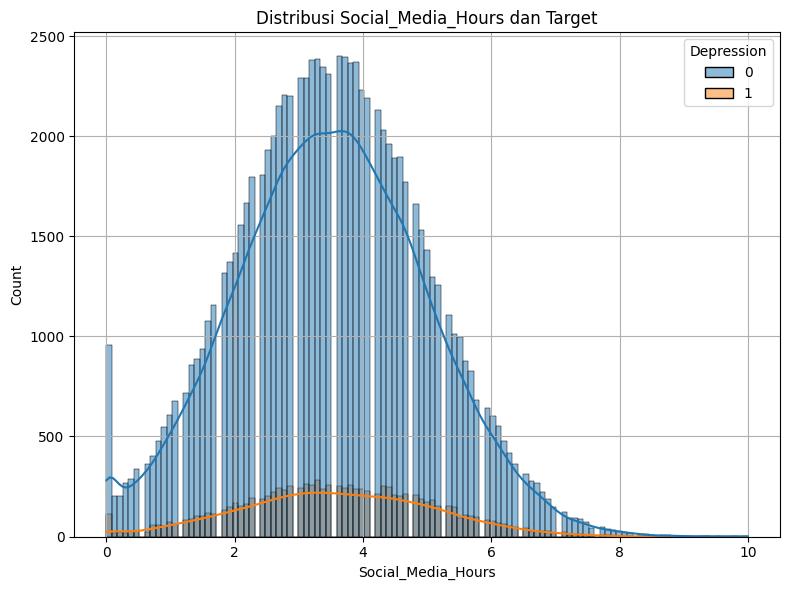

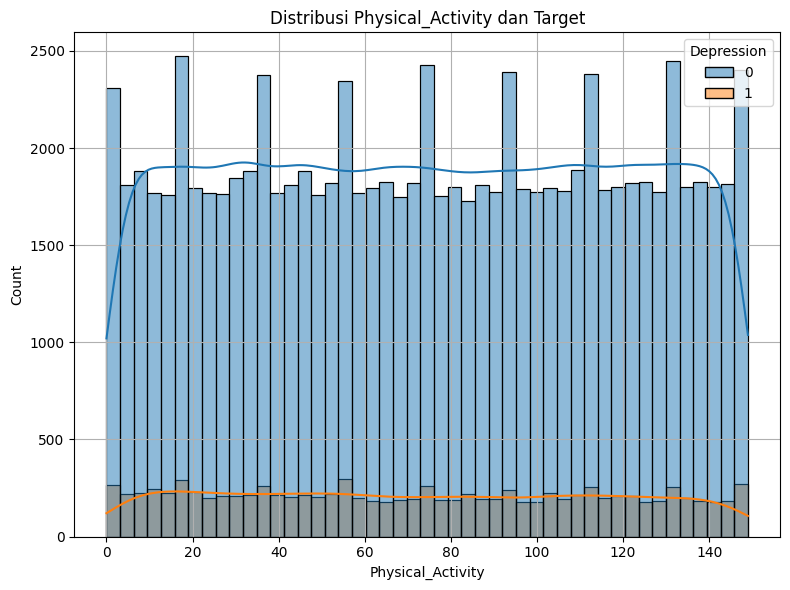

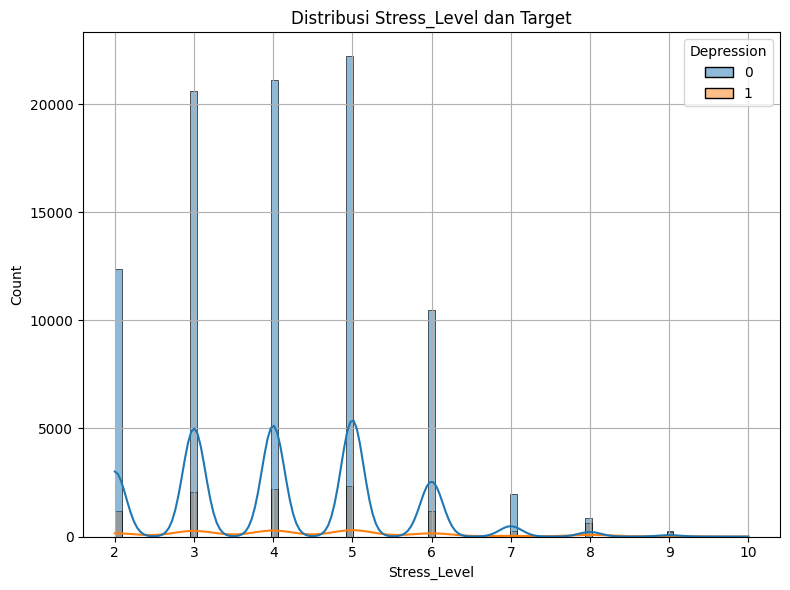

In [74]:
for col in num_col:
    plt.figure(figsize=(8,6))
    plt.title(f'Distribusi {col} dan Target')
    sns.histplot(data=df, x=col, hue='Depression', kde=True)
    plt.tight_layout()
    plt.grid()
    plt.show()

#### Disrtibusi Target

<Axes: title={'center': 'Distribusi Target'}>

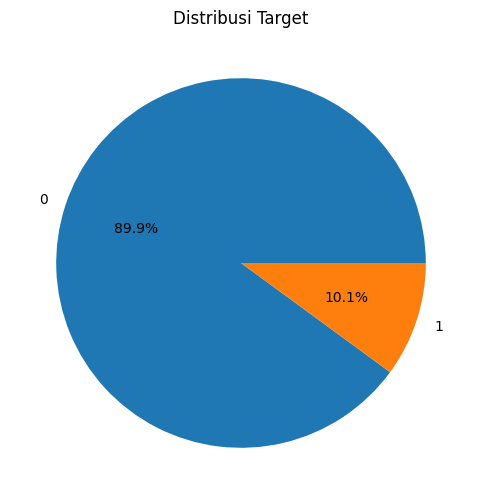

In [75]:
plt.figure(figsize=(8,6))
df['Depression'].value_counts().plot.pie(autopct='%1.1f%%', title='Distribusi Target')

> Insight
- Tidak ada korelasi positif antar fitur. 
- Ada sedikit outlier pada fitur
- Distribusi target tidak seibang. Data 0 (False) mendominasi

## **3. Preprocessing Data**

### 3.1 Encode Fitur Object

In [76]:
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 100000 non-null  int64  
 1   Gender              100000 non-null  int64  
 2   Department          100000 non-null  int64  
 3   CGPA                100000 non-null  float64
 4   Sleep_Duration      100000 non-null  float64
 5   Study_Hours         100000 non-null  float64
 6   Social_Media_Hours  100000 non-null  float64
 7   Physical_Activity   100000 non-null  int64  
 8   Stress_Level        100000 non-null  int64  
 9   Depression          100000 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 7.6 MB


### 3.2 Independent dan Dependent

In [78]:
X = df.drop('Depression', axis=1)
y = df['Depression']

### 3.3 Split Data Train Test

In [79]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    idx = np.random.permutation(len(X))
    split = int(len(X) * size)

    X_train = X.iloc[idx[:split]]
    X_test = X.iloc[idx[split:]]
    y_train = y.iloc[idx[:split]]
    y_test = y.iloc[idx[split:]]

    return X_train, X_test, y_train, y_test

In [80]:
X_train, X_test, y_train, y_test = split_data(X, y)
for val in [X_train, X_test, y_train, y_test]:
    print(val.shape)

(80000, 9)
(20000, 9)
(80000,)
(20000,)


### 3.4 Random Sampling

In [81]:
def hybrid_resample_numpy(X, y, target_ratio=1.0):
    np.random.seed(42)
    
    majority_mask = y == 0
    minority_mask = y == 1
    
    X_major = X[majority_mask]
    y_major = y[majority_mask]
    X_minor = X[minority_mask]
    y_minor = y[minority_mask]
    
    n_major = len(X_major)
    n_minor = len(X_minor)
    

    target_major = int(n_minor * 2) 
    
    target_major = min(20000, n_major)
    target_minor = target_major  # balance
    
    major_idx = np.random.choice(n_major, size=target_major, replace=False)
    X_major_down = X_major[major_idx]
    y_major_down = y_major[major_idx]
    
    minor_idx = np.random.choice(n_minor, size=target_minor, replace=True)
    X_minor_up = X_minor[minor_idx]
    y_minor_up = y_minor[minor_idx]
    
    # Combine
    X_res = np.vstack([X_major_down, X_minor_up])
    y_res = np.hstack([y_major_down, y_minor_up])
    
    # Shuffle
    shuffle_idx = np.random.permutation(len(X_res))
    return X_res[shuffle_idx], y_res[shuffle_idx]

### 3.5 Smote Sampling

In [82]:
def simple_smote_numpy(X_minor, y_minor, target_n, k=5):
    n_samples, n_features = X_minor.shape
    n_synthetic = target_n - n_samples
    
    # Generate synthetic samples
    synthetic_X = []
    
    for _ in range(n_synthetic):
        idx = np.random.randint(0, n_samples)
        sample = X_minor[idx]
        
        neighbor_idx = np.random.randint(0, n_samples)
        while neighbor_idx == idx:
            neighbor_idx = np.random.randint(0, n_samples)
        neighbor = X_minor[neighbor_idx]
        
        alpha = np.random.random()
        synthetic = sample + alpha * (neighbor - sample)
        synthetic_X.append(synthetic)
    
    X_synthetic = np.array(synthetic_X)
    y_synthetic = np.full(len(X_synthetic), y_minor[0])  # same class
    
    return np.vstack([X_minor, X_synthetic]), np.hstack([y_minor, y_synthetic])

def hybrid_with_simple_smote(X, y, target_per_class=20000):
    majority_mask = y == 0
    minority_mask = y == 1
    
    X_major = X[majority_mask]
    X_minor = X[minority_mask]
    y_minor = y[minority_mask]
    
    # Undersample majority
    major_idx = np.random.choice(len(X_major), target_per_class, replace=False)
    X_major_bal = X_major[major_idx]
    y_major_bal = np.zeros(target_per_class)
    
    # Simple SMOTE minority
    X_minor_bal, y_minor_bal = simple_smote_numpy(X_minor, y_minor, target_per_class)
    
    # Combine
    X_res = np.vstack([X_major_bal, X_minor_bal])
    y_res = np.hstack([y_major_bal, y_minor_bal])
    
    # Shuffle
    shuffle_idx = np.random.permutation(len(X_res))
    return X_res[shuffle_idx], y_res[shuffle_idx]

In [83]:
X_train_smote, y_train_smote = hybrid_with_simple_smote(X_train.values, y_train.values)

print(X_train_smote.shape)
print(y_train_smote.shape)

(40000, 9)
(40000,)


In [84]:
X_train_random, y_train_random = hybrid_resample_numpy(X_train.values, y_train.values)

print(X_train_random.shape)
print(y_train_random.shape)

(40000, 9)
(40000,)


## **4. Model**

### 4.1 Linear Regresi

In [85]:
def bias(X):
    return np.c_[np.ones(X.shape[0]), X]
    
def predict(X_train, y_train, X_test, alpha=1.0):
    X_train_b, X_test_b = bias(X_train), bias(X_test)
    I = np.eye(X_train_b.shape[1])
    I[0, 0] = 0
    
    beta = np.linalg.inv(X_train_b.T @ X_train_b + alpha * I) @ X_train_b.T @ y_train
    y_pred_continuous = X_test_b @ beta
    
    # Thresholding buat dapetin class
    y_pred_class = (y_pred_continuous > 0.5).astype(int)
    
    return y_pred_class, y_pred_continuous

In [86]:
y_pred_train, _ = predict(X_train, y_train, X_train)
y_pred_test, _ = predict(X_train, y_train, X_test)

y_pred_test_smote, _ = predict(X_train_smote, y_train_smote, X_test)
y_pred_train_smote, _ = predict(X_train_smote, y_train_smote, X_train_smote)

y_pred_train_random, _ = predict(X_train_random, y_train_random, X_train_random)
y_pred_test_random, _ = predict(X_train_random, y_train_random, X_test)

## **5. Evaluasi**

In [116]:
def evaluate(y_val, y_val2, title='Train'):
    y_true = np.array(y_val)
    y_pred = np.array(y_val2)
    classes = np.unique(y_val)

    accuracy = []
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    print(f'\nEvaluasi {title}')
    print('Akurasi      :', np.mean(y_true == y_pred))
    print(f'Precision   :  {precision[0].item():.4f}')
    print(f'Recall      :  {recall[0].item():.4f}')
    print(f'F1          :  {f1[0].item():.4f}')

In [88]:
def evalauasi(y_true, y_pred, title='Train'):
    RSS = np.sum((y_true - y_pred)**2)
    TSS = np.sum((y_true - y_true.mean())**2)

    R2 = 1 - RSS / TSS
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)

    print(f'\nEvaluasi {title}')
    print(f'R2      : {R2:.4f}')
    print(f'MAE     : {mae:.4f}')
    print(f'MSE     : {mse:.4f}')
    print(f'RMSE    : {rmse:.4f}')

#### Data Asli


In [117]:
evaluate(y_train, y_pred_train)
evaluate(y_test, y_pred_test, title='Test')

evalauasi(y_train.values, y_pred_train)
evalauasi(y_test.values, y_pred_test, title='Test')


Evaluasi Train
Akurasi      : 0.899375
Precision   :  0.8994
Recall      :  1.0000
F1          :  0.9470

Evaluasi Test
Akurasi      : 0.8994
Precision   :  0.8994
Recall      :  1.0000
F1          :  0.9470

Evaluasi Train
R2      : -0.1119
MAE     : 0.1006
MSE     : 0.1006
RMSE    : 0.3172

Evaluasi Test
R2      : -0.1119
MAE     : 0.1006
MSE     : 0.1006
RMSE    : 0.3172


#### Data Smote

In [118]:
evaluate(y_train_smote, y_pred_train_smote)
evaluate(y_test, y_pred_test_smote, title='Test')

evalauasi(y_train_smote, y_pred_train_smote)
evalauasi(y_test, y_pred_test_smote, title='Test')


Evaluasi Train
Akurasi      : 0.649525
Precision   :  0.6617
Recall      :  0.6120
F1          :  0.6359

Evaluasi Test
Akurasi      : 0.629
Precision   :  0.9473
Recall      :  0.6221
F1          :  0.7510

Evaluasi Train
R2      : -0.4019
MAE     : 0.3505
MSE     : 0.3505
RMSE    : 0.5920

Evaluasi Test
R2      : -3.1004
MAE     : 0.3710
MSE     : 0.3710
RMSE    : 0.6091


#### Data Random

In [119]:
evaluate(y_train_random, y_pred_train_random)
evaluate(y_test, y_pred_test_random, title='Test')

evalauasi(y_train_random, y_pred_train_random)
evalauasi(y_test, y_pred_test_random, title='Test')


Evaluasi Train
Akurasi      : 0.648675
Precision   :  0.6600
Recall      :  0.6134
F1          :  0.6358

Evaluasi Test
Akurasi      : 0.63245
Precision   :  0.9471
Recall      :  0.6263
F1          :  0.7540

Evaluasi Train
R2      : -0.4053
MAE     : 0.3513
MSE     : 0.3513
RMSE    : 0.5927

Evaluasi Test
R2      : -3.0622
MAE     : 0.3675
MSE     : 0.3675
RMSE    : 0.6063


## **6. GUI**

In [124]:
col = [    
    'Age',
    'Gender',
    'Department',
    'CGPA',
    'Sleep_Duration',
    'Study_Hours',
    'Social_Media_Hours',
    'Physical_Activity',
    'Stress_Level'
]
n_col = len(col)

gender_map = {'Male':0, 'Female':1}
departmendt_map = {'Science':0, 'Engineering':1, 'Arts':2, 'Medical':3,'Business':4}



def submit():
    try:
        input_data = []
        for i, feature in enumerate(col):
            value = entries[i].get().strip()
            if not value:
                raise ValueError(f'{feature} Ndak boleh kosong')
            
            if feature == 'Gender':
                if value in gender_map:
                    encoded_val = gender_map[value]
                else:
                    encoded_val = float(value)
                input_data.append(encoded_val)
            
            elif feature == 'Department':
                if value in departmendt_map:
                    encoded_val = departmendt_map[value]
                else:
                    encoded_val = float(value)
                input_data.append(encoded_val)
            else:
                input_data.append(float(value))
        X_input = np.array([input_data])

        y_pred_class, _ = predict(X_train_smote, y_train_smote, X_input)
        pred = y_pred_class[0]

        if pred == 1:
            messagebox.showinfo('Done','Mahasiswa Depresi ❌💔')
        else:
            messagebox.showinfo('Done', 'Mahasiswa Tidak Depresi ✅💚')
    except ValueError:
        messagebox.showerror('Error', 'Masukan value yang benar!')


root = tk.Tk()
root.configure(bg='#131313')
root.geometry('480x530')
root.title('Cek Kesehatan Mental Mahasiswa')
entries = []

frame = tk.Frame(root, bg='#131313')
frame.place(relx=0.5, rely=0.45, anchor='center')

title_label = tk.Label(
    frame,
    text='Cek Kesehatan Mental Mahasiswa',
    font=('Helvetica', 16, 'bold'),
    bg='#131313',
    fg='#ffffff'
)
title_label.grid(row=0, column=0, columnspan=2)

intruksi_label = tk.Label(
    frame,
    text='Masukan Data Dibawah 👇',
    font=('Helvetica', 8),
    bg='#131313',
    fg='#7c7e82'
)
intruksi_label.grid(row=1, column=0, columnspan=2)

for i, feature in enumerate(col):
    label = tk.Label(
        frame, 
        text=f'{feature} :',
        font=('Helvetica', 11),
        bg='#131313',
        fg='#ffffff'
    )
    label.grid(row=i+2, column=0, pady=5)


    entry = tk.Entry(
        frame,
        font=('Helvetica', 12),
        bg='#2e2e2e',
        fg='#ffffff'
    )
    entry.grid(row=i+2, column=1, pady=5)
    entries.append(entry)
    
button = tk.Button(
    frame,
    text='Cek!',
    font=('Helvetica', 15),
    bg='#18ab27',
    command=submit
)
button.grid(row=n_col+2, columnspan=2, ipadx=15, pady=10)

root.mainloop()

In [ ]:
df[df['Depression'] == 1].head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
6,18,0,0,2.14,4.4,4.0,3.1,73,8,1
14,22,1,2,2.91,5.1,0.6,2.4,72,3,1
50,19,1,0,2.42,9.3,5.5,6.6,100,5,1
59,20,1,1,3.42,7.4,4.2,1.1,8,3,1
61,22,1,4,2.10,4.6,1.3,5.4,134,8,1


In [107]:
df[df['Depression'] == 0].head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,1,0,3.50,7.3,3.3,3.4,114,5,0
1,20,0,1,2.72,5.5,7.2,6.0,142,2,0
2,20,0,3,3.01,5.4,2.3,1.8,137,3,0
3,21,0,1,3.63,8.1,2.0,4.6,130,3,0
4,19,0,2,3.14,6.8,2.6,4.3,4,6,0


<center>Terimakasih ❤️</center>

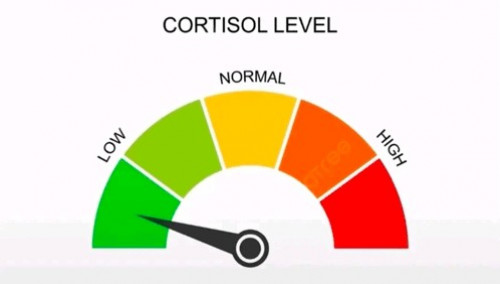
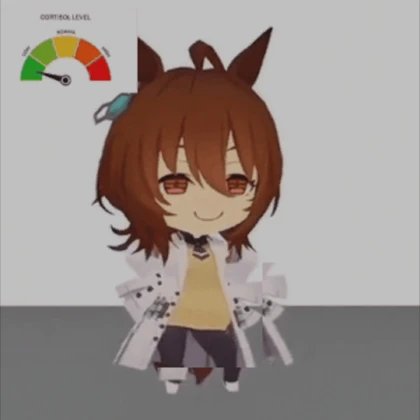